In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_pickle("housing_cleaned.pkl")
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,...,0.0,1955,0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,400.0,1951,1991,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,0.0,1933,0,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,...,910.0,1965,0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,...,0.0,1987,0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0


In [12]:
df_price_sorted = df.sort_values(by = "price", ascending = False).reset_index(drop=True)
df_price_sorted.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,6762700020,6.0,8.00,12050.0,27600.0,2.5,0,3,4,13,...,3480.0,1910,1987,98102,47.6298,-122.323,3940.0,8800.0,2014-10-13,7700000.0
1,9808700762,5.0,4.50,10040.0,37325.0,2.0,1,2,3,11,...,2360.0,1940,2001,98004,47.6500,-122.214,3930.0,25449.0,2014-06-11,7060000.0
2,9208900037,6.0,7.75,9890.0,31374.0,2.0,0,4,3,13,...,1030.0,2001,0,98039,47.6305,-122.240,4540.0,42730.0,2014-09-19,6890000.0
3,2470100110,5.0,5.75,9200.0,35069.0,2.0,0,0,3,13,...,3000.0,2001,0,98039,47.6289,-122.233,3560.0,24345.0,2014-08-04,5570000.0
4,8907500070,5.0,5.00,8000.0,23985.0,2.0,0,4,3,12,...,1280.0,2009,0,98004,47.6232,-122.220,4600.0,21750.0,2015-04-13,5350000.0


In [36]:
avg_price_by_zip = df.groupby("zipcode")["price"].mean().sort_values()
avg_price_by_zip.info()

<class 'pandas.Series'>
Index: 70 entries, 98002 to 98039
Series name: price
Non-Null Count  Dtype  
--------------  -----  
70 non-null     float64
dtypes: float64(1)
memory usage: 1.1 KB


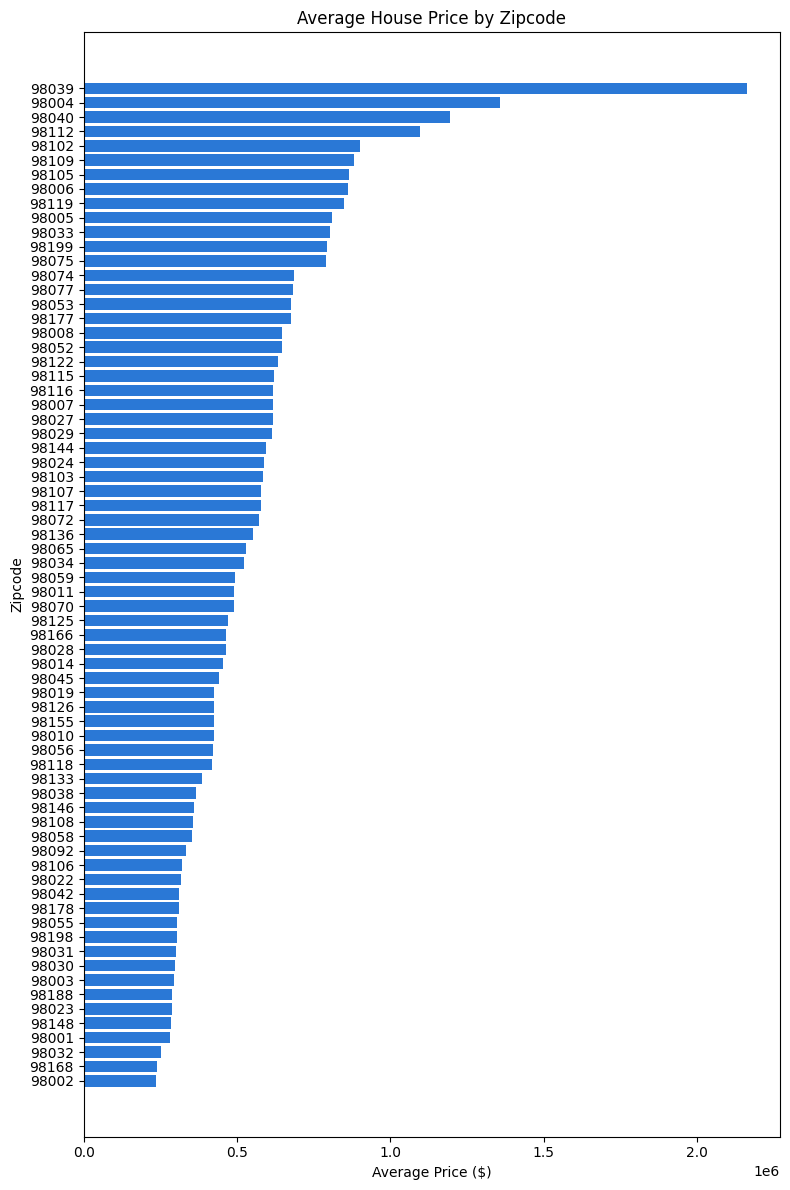

In [21]:
fig, ax = plt.subplots(figsize=(8, 12))
ax.barh(avg_price_by_zip.index.astype(str), avg_price_by_zip.values, color="#2a78d6")
ax.set_xlabel("Average Price ($)")
ax.set_ylabel("Zipcode")
ax.set_title("Average House Price by Zipcode")
plt.tight_layout()
plt.show()


In [24]:
lower_cutoff = avg_price_by_zip.quantile(0.33)
upper_cutoff = avg_price_by_zip.quantile(0.67)

middle_class_zips = avg_price_by_zip[(avg_price_by_zip >= lower_cutoff) & (avg_price_by_zip <= upper_cutoff)]
print(middle_class_zips)

zipcode
98056    420895.475369
98010    423665.990000
98155    423736.905830
98126    424734.604520
98019    424815.063158
98045    440232.313636
98014    455617.112903
98028    462488.869258
98166    464322.389764
98125    469928.767726
98070    489382.017094
98011    490377.107692
98059    493625.309829
98034    521740.014679
98065    529629.782468
98136    551768.520913
98072    570073.520147
98117    576834.808318
98107    579109.808271
98103    585048.779070
98024    586120.875000
98144    594706.542274
98029    612642.738318
98027    617053.966019
Name: price, dtype: float64


In [37]:
middle_class_zip_list = middle_class_zips.index.tolist()
df_middle_class_zip = df[df["zipcode"].isin(middle_class_zip_list)].reset_index(drop=True)
df_middle_class_zip.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,6414100192,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,...,400.0,1951,1991,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0
1,5631500400,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,...,0.0,1933,0,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0
2,2487200875,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,...,910.0,1965,0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0
3,114101516,3.0,1.00,1430.0,19901.0,1.5,0,0,4,7,...,0.0,1927,0,98028,47.7558,-122.229,1780.0,12697.0,2014-05-28,310000.0
4,1175000570,5.0,2.00,1810.0,4850.0,1.5,0,0,3,7,...,0.0,1900,0,98107,47.6700,-122.394,1360.0,4850.0,2015-03-12,530000.0


In [42]:
df_middle_class_zip["id"].duplicated().value_counts()

id
False    7482
True       50
Name: count, dtype: int64

In [47]:
duplicate_mask = df_middle_class_zip["id"].duplicated(keep=False)
duplicate_rows = df_middle_class_zip[duplicate_mask]
duplicate_rows = duplicate_rows.sort_values("id")
duplicate_rows

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
2431,526059224,4.0,1.75,1650.0,7276.0,1.0,0,0,3,7,...,640.0,1977,0,98011,47.7721,-122.206,1840.0,8550.0,2014-09-23,260000.0
2432,526059224,4.0,1.75,1650.0,7276.0,1.0,0,0,3,7,...,640.0,1977,0,98011,47.7721,-122.206,1840.0,8550.0,2015-02-06,470000.0
3122,722039087,2.0,1.00,990.0,57499.0,1.0,0,0,2,6,...,0.0,1949,0,98070,47.4145,-122.463,2090.0,27442.0,2015-05-04,329000.0
3121,722039087,2.0,1.00,990.0,57499.0,1.0,0,0,2,6,...,0.0,1949,0,98070,47.4145,-122.463,2090.0,27442.0,2014-09-23,220500.0
4180,1217000340,3.0,1.00,1840.0,8100.0,1.0,0,0,4,7,...,920.0,1953,0,98166,47.4550,-122.350,1250.0,8100.0,2015-02-19,340000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,9407110710,3.0,1.75,1510.0,8400.0,1.0,0,0,2,7,...,530.0,1979,0,98045,47.4476,-121.771,1500.0,10125.0,2015-02-26,322000.0
5133,9834200305,3.0,1.00,1790.0,3876.0,1.5,0,0,5,7,...,700.0,1904,0,98144,47.5750,-122.288,1360.0,4080.0,2014-07-16,350000.0
5134,9834200305,3.0,1.00,1790.0,3876.0,1.5,0,0,5,7,...,700.0,1904,0,98144,47.5750,-122.288,1360.0,4080.0,2015-02-10,615000.0
347,9834200885,4.0,2.50,2080.0,4080.0,1.0,0,0,5,7,...,1040.0,1962,0,98144,47.5720,-122.290,1340.0,4080.0,2015-04-20,550000.0


In [65]:
print(df["date"].min(), df["date"].max())


2014-05-02 00:00:00 2015-05-27 00:00:00


In [50]:
pairs = (
    duplicate_rows
    .sort_values(["id", "date"])
    .groupby("id")
    .agg(
        first_date=("date", "first"),
        second_date=("date", "last"),
        first_price=("price", "first"),
        second_price=("price", "last"),
    )
)
pairs["days_between"] = (pairs["second_date"] - pairs["first_date"]).dt.days
pairs["price_change_pct"] = (pairs["second_price"] - pairs["first_price"]) / pairs["first_price"] * 100


In [51]:
pairs["days_between"].corr(pairs["price_change_pct"])

np.float64(-0.0016291355381635078)

In [52]:
pairs["sale_month"] = pairs["second_date"].dt.month
pairs.groupby("sale_month")["price_change_pct"].mean()


sale_month
1     38.573120
2     64.528555
3     54.207253
4     40.226456
5     52.372692
8      0.000000
11    37.187781
12    43.300111
Name: price_change_pct, dtype: float64

In [53]:
pairs.groupby("sale_month")["price_change_pct"].size()


sale_month
1      7
2     11
3     11
4     10
5      6
8      1
11     2
12     2
Name: price_change_pct, dtype: int64

In [54]:
monthly_avg_price = df.groupby(df["date"].dt.month)["price"].mean()
monthly_avg_price

date
1     525963.251534
2     508520.051323
3     544057.683200
4     562215.615074
5     550849.746893
6     557534.318182
7     544892.161013
8     536655.212481
9     529723.517787
10    539439.447228
11    522359.903478
12    524799.902041
Name: price, dtype: float64

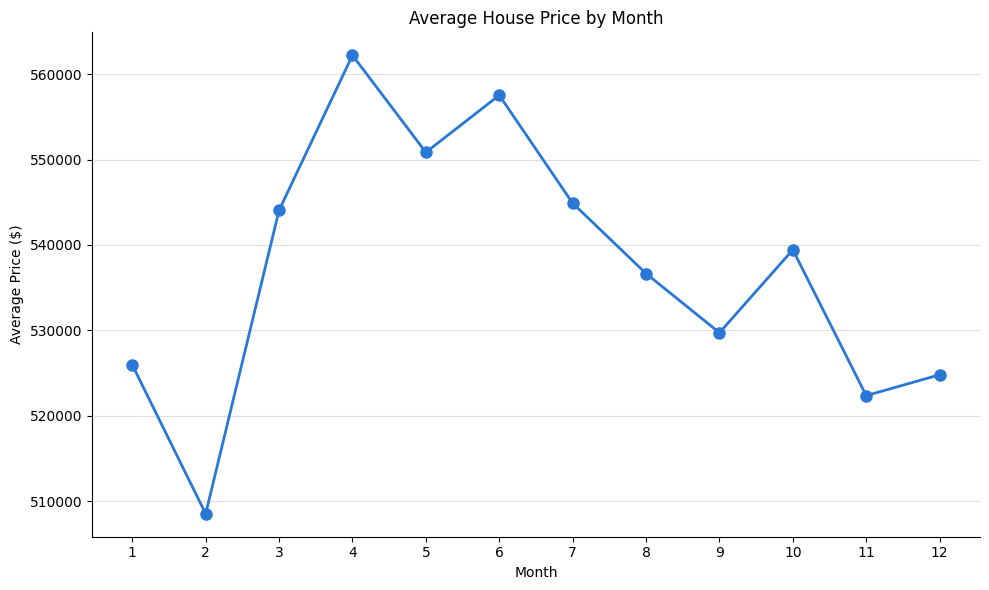

In [57]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly_avg_price.index, monthly_avg_price.values, color="#2a78d6", linewidth=2, marker="o", markersize=8)

ax.set_xlabel("Month")
ax.set_ylabel("Average Price ($)")
ax.set_title("Average House Price by Month")
ax.set_xticks(range(1, 13))
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


In [66]:
monthly_avg_price_mc = df_middle_class_zip.groupby(df_middle_class_zip["date"].dt.month)["price"].mean()
monthly_counts_mc = df_middle_class_zip.groupby(df_middle_class_zip["date"].dt.month)["price"].size()

print(monthly_avg_price_mc)
print(monthly_counts_mc)


date
1     521477.507331
2     501244.390777
3     518483.067103
4     541898.038023
5     514235.388954
6     516604.239951
7     522553.815824
8     503794.862170
9     497588.241611
10    519218.414634
11    514889.567404
12    508526.556436
Name: price, dtype: float64
date
1     341
2     412
3     611
4     789
5     851
6     821
7     771
8     682
9     596
10    656
11    497
12    505
Name: price, dtype: int64


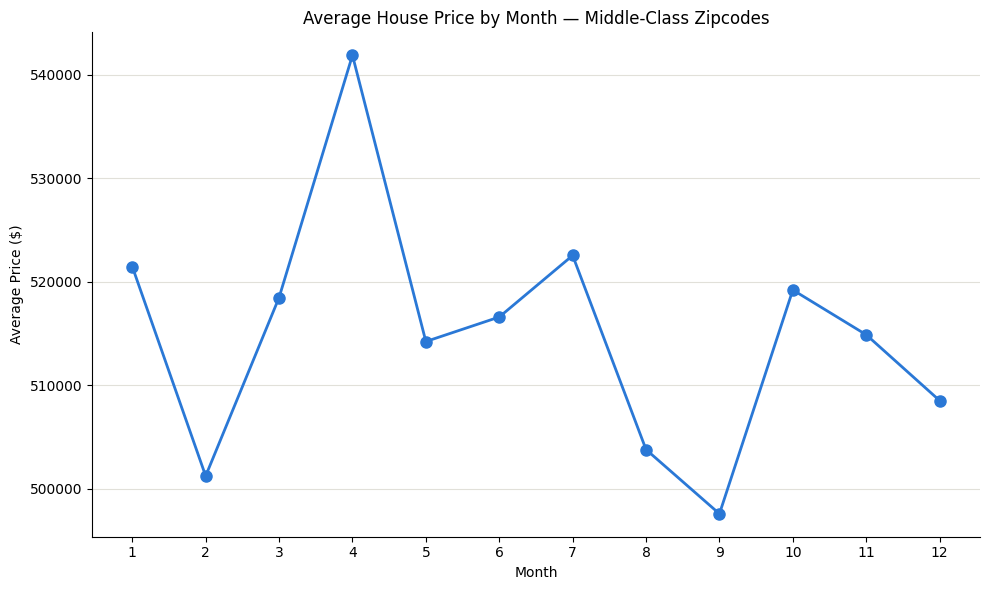

In [67]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly_avg_price_mc.index, monthly_avg_price_mc.values, color="#2a78d6", linewidth=2, marker="o", markersize=8)

ax.set_xlabel("Month")
ax.set_ylabel("Average Price ($)")
ax.set_title("Average House Price by Month — Middle-Class Zipcodes")
ax.set_xticks(range(1, 13))
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


In [68]:
df_middle_class_zip["price_per_sqft"] = df_middle_class_zip["price"] / df_middle_class_zip["sqft_living"]

df_middle_class_zip[["price_per_sqft", "grade", "condition"]].corr()


,price_per_sqft,grade,condition
price_per_sqft,1.000000,-0.097010,0.097708
grade,-0.097010,1.000000,-0.215119
condition,0.097708,-0.215119,1.000000


In [69]:
df_middle_class_zip["is_renovated"] = df_middle_class_zip["yr_renovated"] != 0

renovation_comparison = df_middle_class_zip.groupby("is_renovated")["price_per_sqft"].agg(["mean", "count"])
renovation_comparison


,mean,count
is_renovated,,
False,272.002306,7290
True,306.559737,242


renovated homes in this tier sold for ~13% more per soft

In [70]:
zip_price_per_sqft = (
    df_middle_class_zip
    .groupby("zipcode")["price_per_sqft"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
zip_price_per_sqft


,mean,count
zipcode,,
98107,382.968248,266
98103,369.882756,602
98117,363.546251,553
98136,337.245108,263
98144,312.285969,343
98126,292.803935,354
98125,282.680191,409
98070,277.849906,117
98029,272.068868,321


"if your house sits in the upper half of this list (98107/98103/98117/98136), you're already well-positioned — if it's in the lower half (98019/98059/98010/98065), temper profit expectations, and the timing/renovation levers matter more for you than for someone higher up."